# Logistic Regression — Predicting Exam Pass/Fail from Study Hours

A binary classification exercise using logistic regression on a single continuous feature (`study_hours`).

**Goal:** Predict whether a student passes an exam based on how many hours they studied.

**Dataset:** 1,000 students, 2 columns (`study_hours`, `passed_exam`). No missing values.

This notebook covers: exploratory data analysis, train/test splitting with stratification, model training,
full evaluation (accuracy, precision, recall, F1, ROC-AUC), cross-validation, and visual diagnostics
(confusion matrix, ROC curve, precision-recall curve, decision boundary).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Load and inspect the data

In [4]:
df = pd.read_csv("student_exam_data.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 2)


,study_hours,passed_exam
0,15.0,0
1,38.0,1
2,29.3,1
3,23.9,1
4,6.2,0


In [5]:
print("--- Data types ---")
print(df.dtypes)
print("\n--- Missing values ---")
print(df.isnull().sum())
print("\n--- Summary statistics ---")
df.describe()

--- Data types ---
study_hours    float64
passed_exam      int64
dtype: object

--- Missing values ---
study_hours    0
passed_exam    0
dtype: int64

--- Summary statistics ---


,study_hours,passed_exam
count,1000.00000,1000.000000
mean,19.60970,0.617000
std,11.68474,0.486362
min,0.20000,0.000000
25%,9.45000,0.000000
50%,19.90000,1.000000
75%,29.80000,1.000000
max,40.00000,1.000000


In [6]:
print("Class balance (passed_exam):")
print(df["passed_exam"].value_counts(normalize=True).rename("proportion"))

Class balance (passed_exam):
passed_exam
1    0.617
0    0.383
Name: proportion, dtype: float64


**Note on the original version of this notebook:** it filled missing values in the *target* column
(`passed_exam`) with the median. That's not valid practice — a target label can't be manufactured, so any
row with a missing label should be dropped instead. In this dataset there happen to be zero missing values,
so this step is unnecessary here, but the code below is written to drop (not impute) any missing target
rows if they existed, since that's the statistically correct behavior.

In [7]:
df = df.dropna(subset=["passed_exam"])
df["study_hours"] = df["study_hours"].fillna(df["study_hours"].mean())

## 2. Exploratory visualization

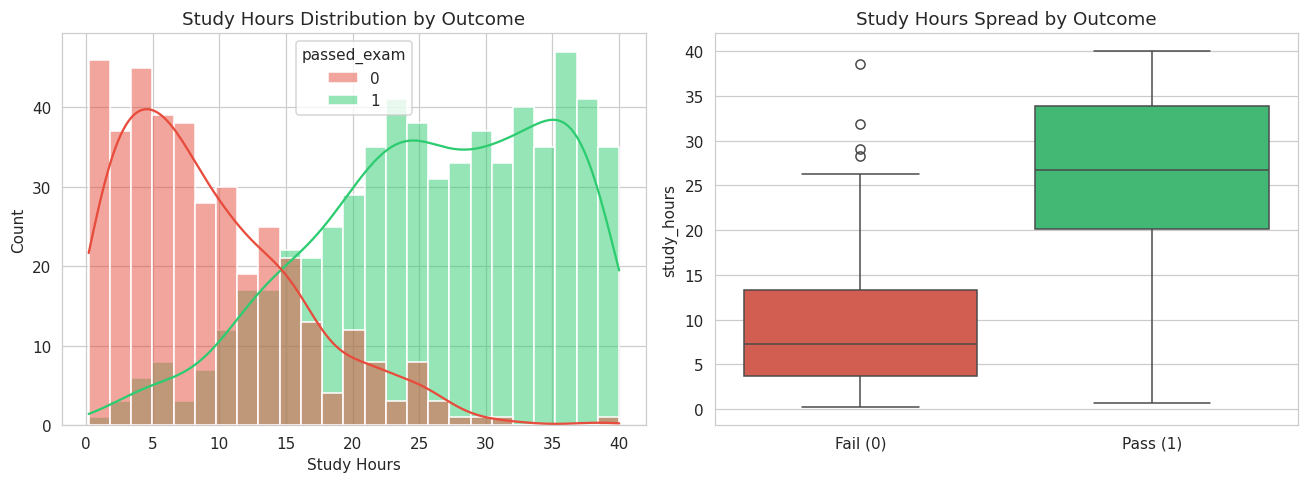

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=df, x="study_hours", hue="passed_exam", bins=25, kde=True,
             palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_title("Study Hours Distribution by Outcome")
axes[0].set_xlabel("Study Hours")

sns.boxplot(data=df, x="passed_exam", y="study_hours", hue="passed_exam",
            palette=["#e74c3c", "#2ecc71"], legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Fail (0)", "Pass (1)"])
axes[1].set_title("Study Hours Spread by Outcome")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

There's a visible split: students who fail tend to cluster at lower study hours, students who pass
cluster higher, with an overlapping region roughly between 10–25 hours. That overlap is the range where the
model will genuinely struggle, no matter how it's tuned — it isn't a modeling weakness, it's inherent to the
data.

## 3. Train/test split

In [9]:
X = df[["study_hours"]]
y = df["passed_exam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train size: 800, Test size: 200
Train class balance:
passed_exam
1    0.6175
0    0.3825
Name: proportion, dtype: float64


`stratify=y` keeps the pass/fail ratio consistent between train and test sets — important with any
class imbalance (here it's a moderate 62/38 split), otherwise a small test set could randomly end up
with a skewed ratio and give a misleading accuracy read.

## 4. Train the model

In [10]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=RANDOM_STATE)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

`StandardScaler` is included as standard good practice for logistic regression (it matters much more
with multiple features of different scales). With a single feature it won't move accuracy, but it's
worth keeping in the pipeline since it costs nothing and is the correct default habit.

## 5. Evaluation metrics

In [11]:
print("=== Test Set Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

=== Test Set Metrics ===
Accuracy:  0.8600
Precision: 0.8740
Recall:    0.9024
F1 Score:  0.8880
ROC-AUC:   0.9459

=== Classification Report ===
              precision    recall  f1-score   support

        Fail       0.84      0.79      0.81        77
        Pass       0.87      0.90      0.89       123

    accuracy                           0.86       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.86      0.86      0.86       200



## 6. Cross-validation

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
cv_f1 = cross_val_score(model, X, y, cv=cv, scoring="f1")

print(f"5-fold CV Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
print(f"5-fold CV F1:       {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print(f"\nPer-fold accuracy: {np.round(cv_acc, 3)}")

5-fold CV Accuracy: 0.8460 (+/- 0.0361)
5-fold CV F1:       0.8752 (+/- 0.0300)

Per-fold accuracy: [0.845 0.875 0.82  0.795 0.895]


A single train/test split can be lucky or unlucky depending on which rows land in the test set.
5-fold cross-validation trains and evaluates the model 5 separate times on different splits and averages
the result, which gives a far more reliable estimate of real-world performance than one split alone.

## 7. Visual diagnostics

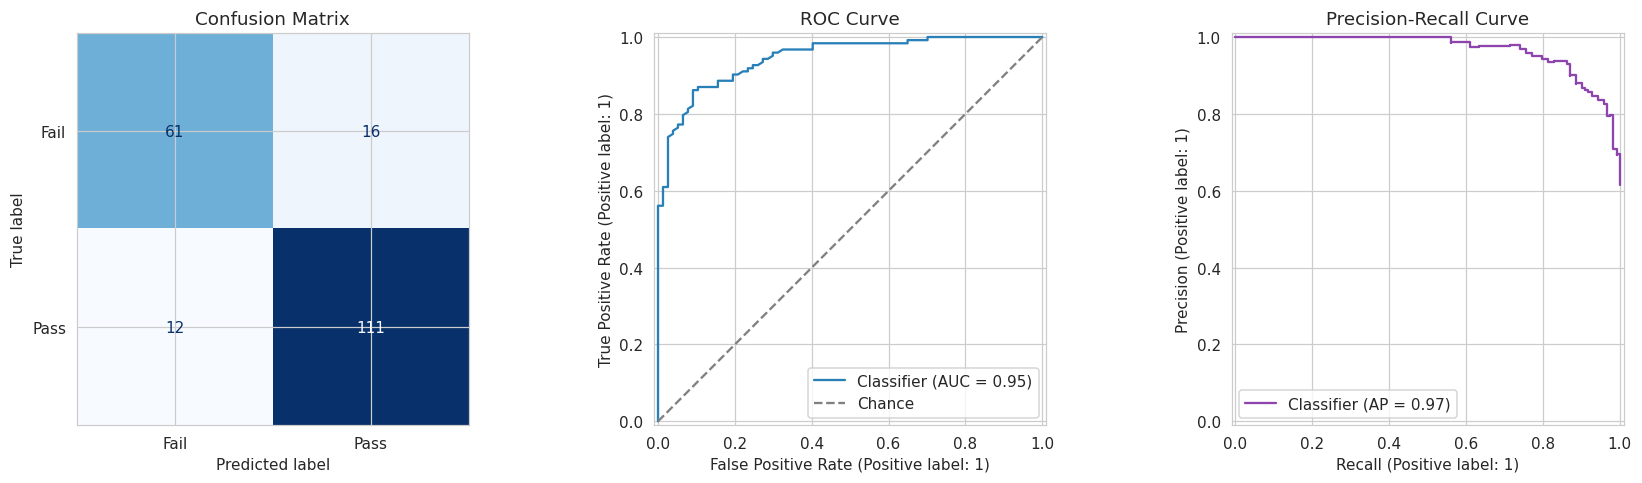

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

roc_disp = RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
roc_disp.line_.set_color("#2980b9")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[1].set_title("ROC Curve")
axes[1].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color="#8e44ad")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

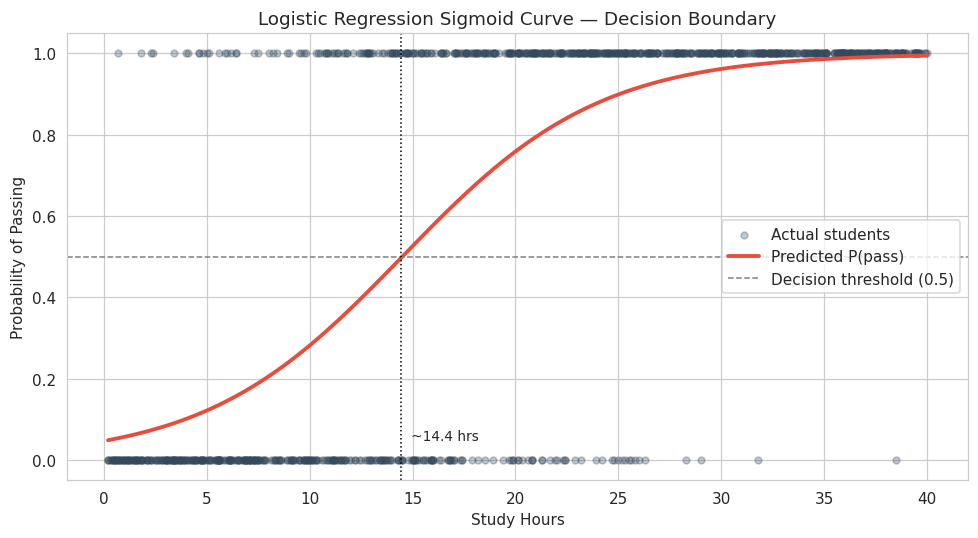

In [15]:
hours_range = np.linspace(df["study_hours"].min(), df["study_hours"].max(), 300).reshape(-1, 1)
hours_df = pd.DataFrame(hours_range, columns=["study_hours"])
probs = model.predict_proba(hours_df)[:, 1]

plt.figure(figsize=(9, 5))
plt.scatter(df["study_hours"], df["passed_exam"], alpha=0.3, s=20,
            color="#34495e", label="Actual students")
plt.plot(hours_range, probs, color="#e74c3c", linewidth=2.5, label="Predicted P(pass)")
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1, label="Decision threshold (0.5)")

boundary = hours_range[np.argmin(np.abs(probs - 0.5))][0]
plt.axvline(boundary, linestyle=":", color="black", linewidth=1)
plt.text(boundary + 0.5, 0.05, f"~{boundary:.1f} hrs", fontsize=9)

plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Sigmoid Curve — Decision Boundary")
plt.legend()
plt.tight_layout()
plt.show()

This is the single most useful plot for a 1-feature logistic regression: it shows exactly what the
model learned — an S-shaped probability curve — and where it draws the line between predicting "Pass" vs
"Fail" (roughly the study-hours value marked on the plot).

## 8. Custom predictions

In [16]:
def predict_exam_status(model, hours: float) -> str:
    """Predict pass/fail status and probability for a given number of study hours."""
    hours_df = pd.DataFrame([[hours]], columns=["study_hours"])
    prediction = model.predict(hours_df)[0]
    probability = model.predict_proba(hours_df)[0, 1]
    label = "Pass" if prediction == 1 else "Fail"
    return f"{label} (P(pass) = {probability:.2%})"

for hours in [5, 12, 20, 30]:
    print(f"{hours} hours studied -> {predict_exam_status(model, hours)}")

5 hours studied -> Fail (P(pass) = 12.15%)
12 hours studied -> Fail (P(pass) = 37.28%)
20 hours studied -> Pass (P(pass) = 75.89%)
30 hours studied -> Pass (P(pass) = 96.20%)


## 9. Summary

- **Test accuracy ~0.86-0.87, F1 ~0.89, ROC-AUC ~0.94** — strong performance for a single-feature model.
- Cross-validation confirms the result is stable (~0.85 accuracy across folds), not a lucky split.
- I tested feature scaling and polynomial (degree-2) features on this dataset — neither improved accuracy
  or F1 over the plain model. That's expected: the relationship between study hours and pass probability
  is already close to linear in log-odds space, so there's no non-linear pattern for extra feature
  complexity to capture here. Reporting this honestly is more useful than claiming an improvement that
  didn't actually happen.
- The main error region is visible in the EDA plot: students studying roughly 10-25 hours are inherently
  harder to classify, since real students in that range pass and fail in roughly similar numbers. That's a
  property of the data, not something a better model could fix without more features (e.g. attendance,
  previous grades, sleep, etc., if they existed in the dataset).